In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

In [111]:
df = pd.read_csv('Cellphone.csv')
df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [112]:
# removing irrelevant columns
df.drop(['Product_id', 'Sale'], axis=1, inplace=True)

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         161 non-null    int64  
 1   weight        161 non-null    float64
 2   resoloution   161 non-null    float64
 3   ppi           161 non-null    int64  
 4   cpu core      161 non-null    int64  
 5   cpu freq      161 non-null    float64
 6   internal mem  161 non-null    float64
 7   ram           161 non-null    float64
 8   RearCam       161 non-null    float64
 9   Front_Cam     161 non-null    float64
 10  battery       161 non-null    int64  
 11  thickness     161 non-null    float64
dtypes: float64(8), int64(4)
memory usage: 15.2 KB


In [114]:
df.rename(columns={'cpu core': 'cpu_core', 'cpu freq': 'cpu_freq', 'internal mem': 'internal_mem'}, inplace=True)

In [115]:
df['Price'] = df['Price'].astype('float64')

In [116]:
df.isnull().sum()

Price           0
weight          0
resoloution     0
ppi             0
cpu_core        0
cpu_freq        0
internal_mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

In [117]:
df.duplicated().sum()

np.int64(78)

In [118]:
df.drop_duplicates(inplace=True)

In [119]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,83.0,2219.084337,763.850279,614.0,1737.50,2258.00,2744.000,4361.0
weight,83.0,169.226506,92.039427,66.0,134.05,152.00,170.000,753.0
resoloution,83.0,5.206024,1.492304,1.4,4.90,5.15,5.500,12.2
ppi,83.0,334.710843,134.002505,121.0,233.00,294.00,428.000,806.0
cpu_core,83.0,4.879518,2.441499,0.0,4.00,4.00,8.000,8.0
cpu_freq,83.0,1.501843,0.595929,0.0,1.20,1.40,1.875,2.7
internal_mem,83.0,24.438410,28.691272,0.0,8.00,16.00,32.000,128.0
ram,83.0,2.201831,1.603925,0.0,1.00,2.00,3.000,6.0
RearCam,83.0,10.469277,6.164116,0.0,5.00,12.00,16.000,23.0
Front_Cam,83.0,4.608434,4.467940,0.0,0.45,5.00,8.000,20.0


In [120]:
# removed entries with both ram and internal memory as 0, as they are likely to be erroneous
df = df[~((df['ram'] == 0) & (df['internal_mem'] == 0))]

In [121]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,82.0,2229.597561,762.485067,614.000,1743.000,2262.000,2744.000,4361.0
weight,82.0,169.278049,92.604624,66.000,134.025,152.000,170.000,753.0
resoloution,82.0,5.212683,1.500246,1.400,5.000,5.175,5.500,12.2
ppi,82.0,336.353659,133.983542,121.000,233.000,294.000,428.000,806.0
cpu_core,82.0,4.890244,2.454555,0.000,4.000,4.000,8.000,8.0
cpu_freq,82.0,1.505524,0.598646,0.000,1.200,1.400,1.875,2.7
internal_mem,82.0,24.736439,28.738280,0.000,8.000,16.000,32.000,128.0
ram,82.0,2.228683,1.594915,0.004,1.000,2.000,3.000,6.0
RearCam,82.0,10.535976,6.171841,0.000,5.000,12.000,16.000,23.0
Front_Cam,82.0,4.664634,4.465820,0.000,0.925,5.000,8.000,20.0


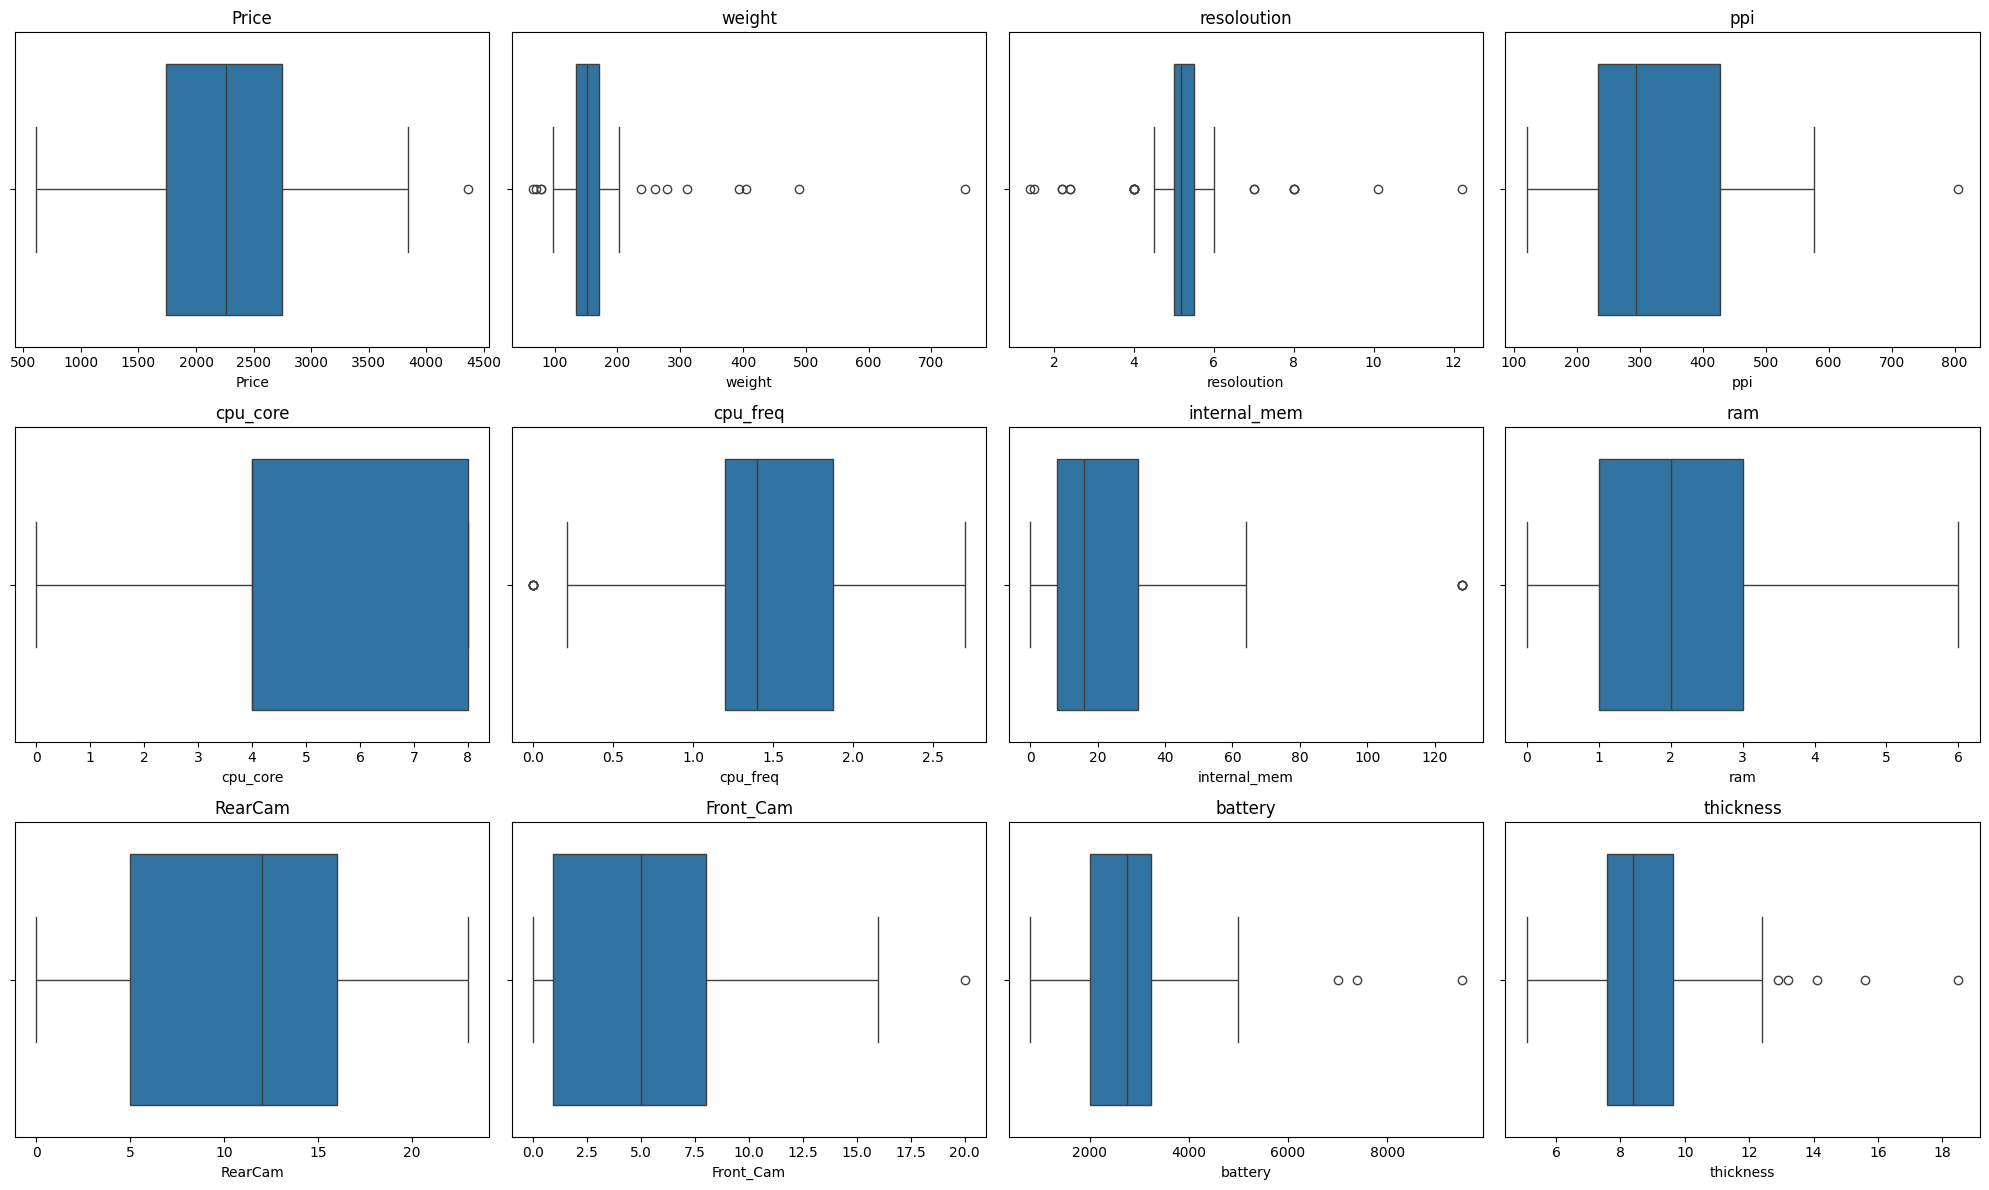

In [122]:
# plotting boxplots for independent variables to check for outliers
numeric_cols = df.select_dtypes(include=np.number).columns
n = len(numeric_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes_box = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes_box = axes_box.flatten()

for ax, col in zip(axes_box, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

for ax in axes_box[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [123]:
def IQR_outliers(p_df, column):
    q1 = p_df[column].quantile(0.25)
    q3 = p_df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return p_df[(p_df[column] < lower_bound) | (p_df[column] > upper_bound)]

for col in df.columns:
    outliers = IQR_outliers(df, col)
    mean_value = df[col].mean()
    if df[col].dtype == np.int64:
        mean_value = np.int64(mean_value)
    
    for index in outliers.index:
        df.at[index, col] = mean_value

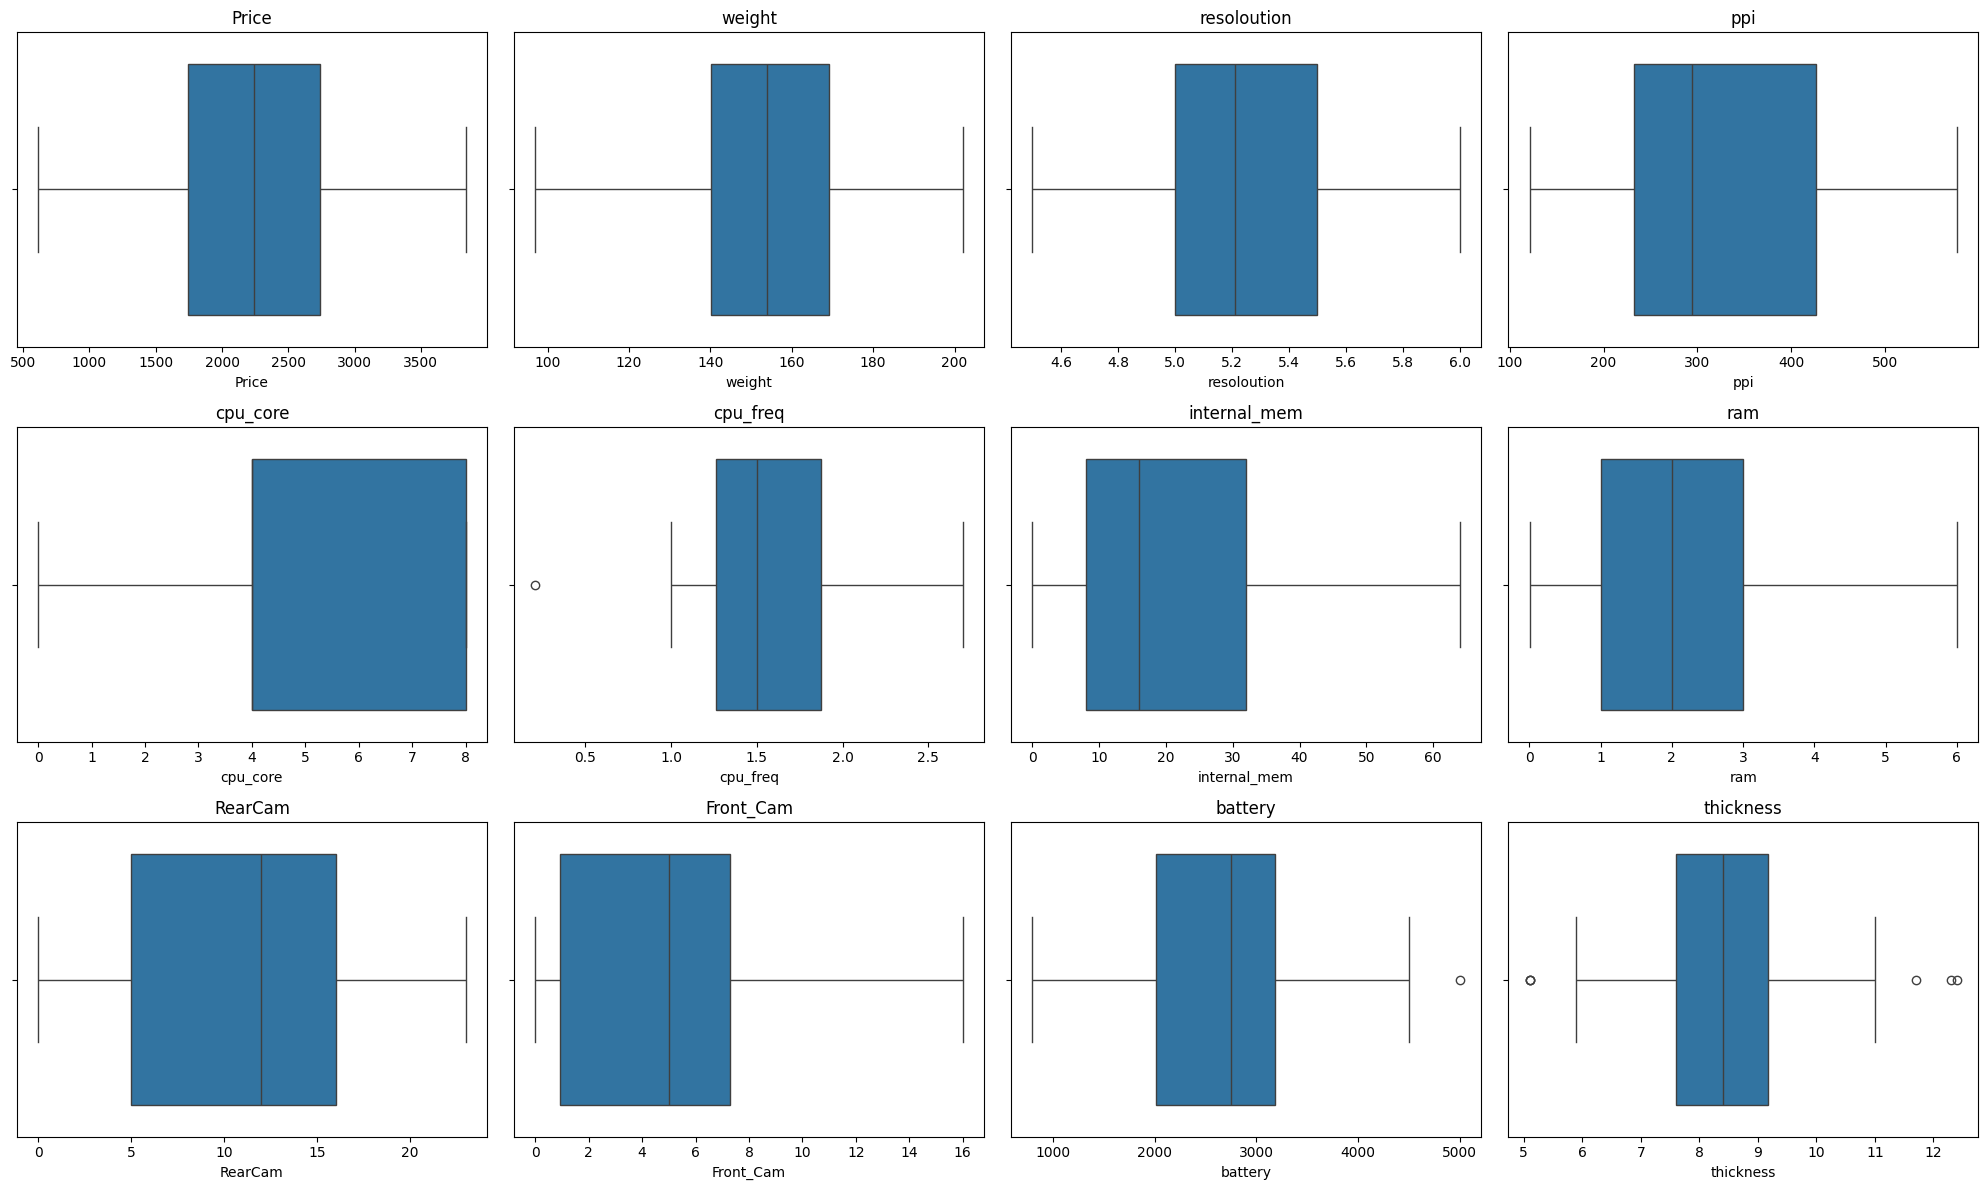

In [124]:
# plotting boxplots for independent variables post handling outliers
numeric_cols = df.select_dtypes(include=np.number).columns
n = len(numeric_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes_box = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes_box = axes_box.flatten()

for ax, col in zip(axes_box, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

for ax in axes_box[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

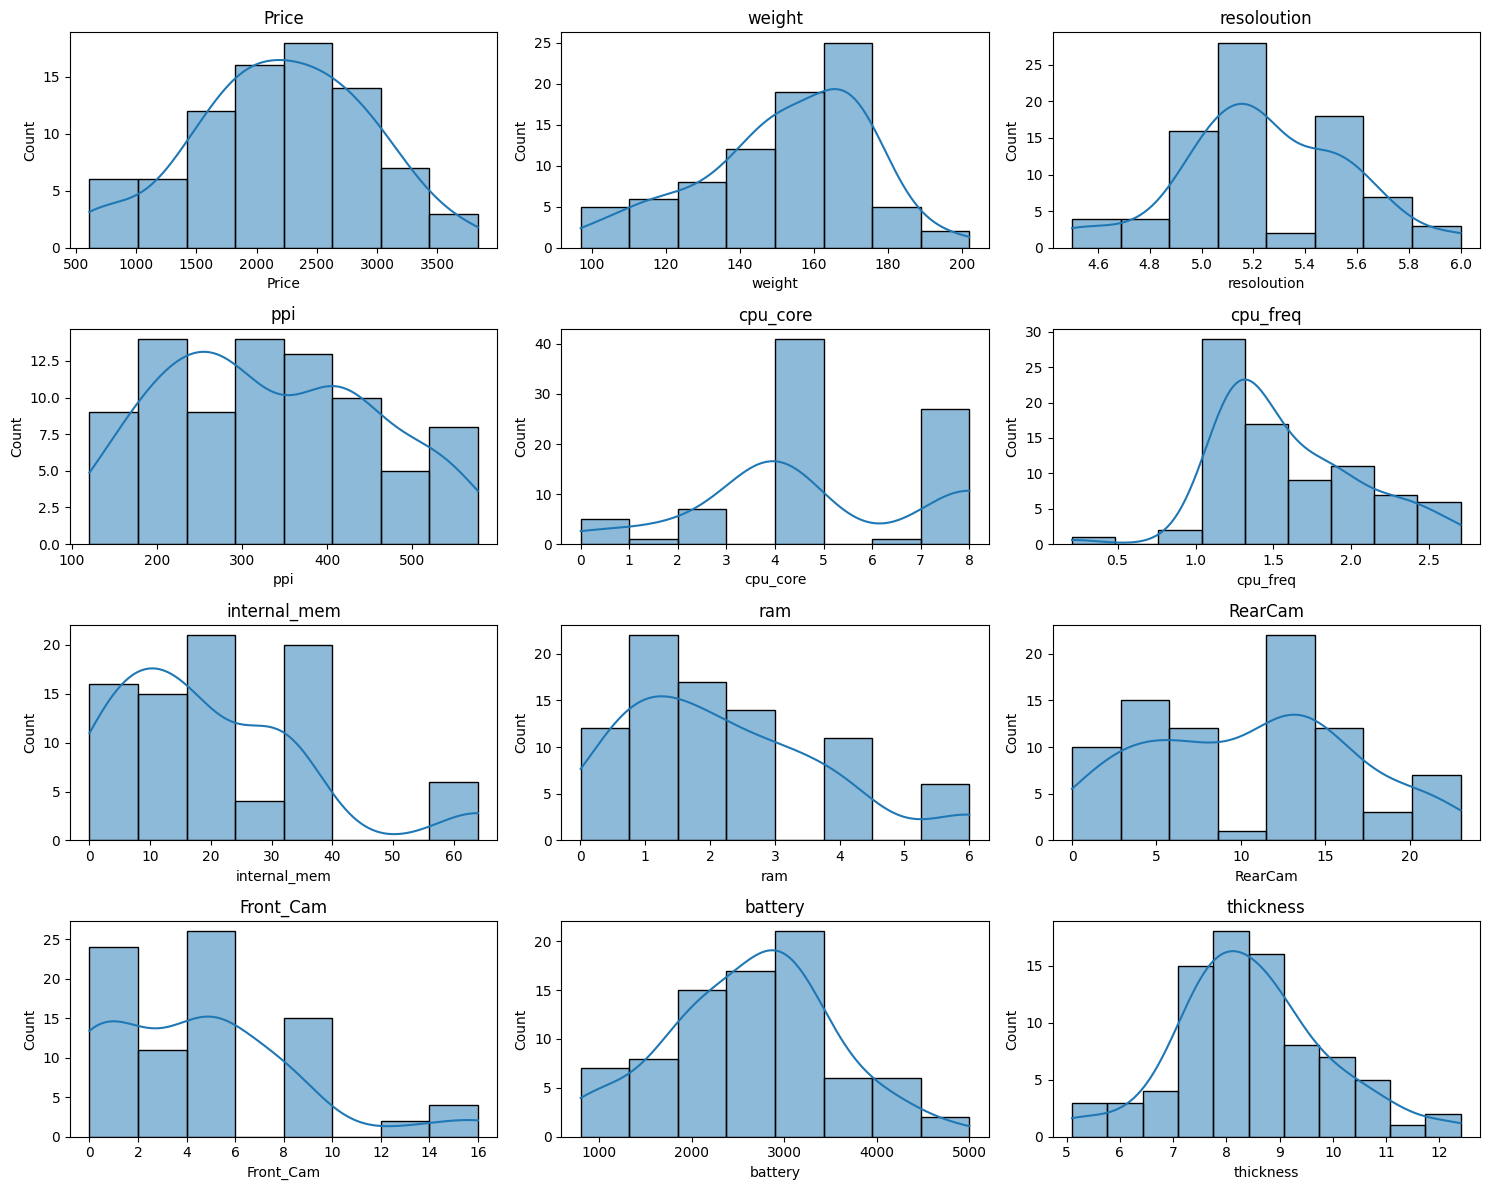

In [125]:
# distribution of independent variables post handling outliers
numeric_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [126]:
# checking skewness of the data
df.skew()

Price          -0.176172
weight         -0.556240
resoloution    -0.044390
ppi             0.201940
cpu_core       -0.024135
cpu_freq        0.462447
internal_mem    1.248173
ram             0.806522
RearCam         0.062256
Front_Cam       1.067429
battery        -0.009015
thickness       0.283772
dtype: float64

In [127]:
# applying transformations to reduce skewness
df_transformed = df.copy()
df_transformed['internal_mem_log'] = np.log1p(df_transformed['internal_mem'])
df_transformed['ram_sqrt'] = np.sqrt(df_transformed['ram'])
df_transformed['Front_Cam_log'] = np.log1p(df_transformed['Front_Cam'])
df_transformed.skew()


Price              -0.176172
weight             -0.556240
resoloution        -0.044390
ppi                 0.201940
cpu_core           -0.024135
cpu_freq            0.462447
internal_mem        1.248173
ram                 0.806522
RearCam             0.062256
Front_Cam           1.067429
battery            -0.009015
thickness           0.283772
internal_mem_log   -1.004145
ram_sqrt           -0.231193
Front_Cam_log      -0.402570
dtype: float64

In [128]:
#removed original columns after transformation
df_transformed.drop(['internal_mem', 'ram', 'Front_Cam'], axis=1, inplace=True)


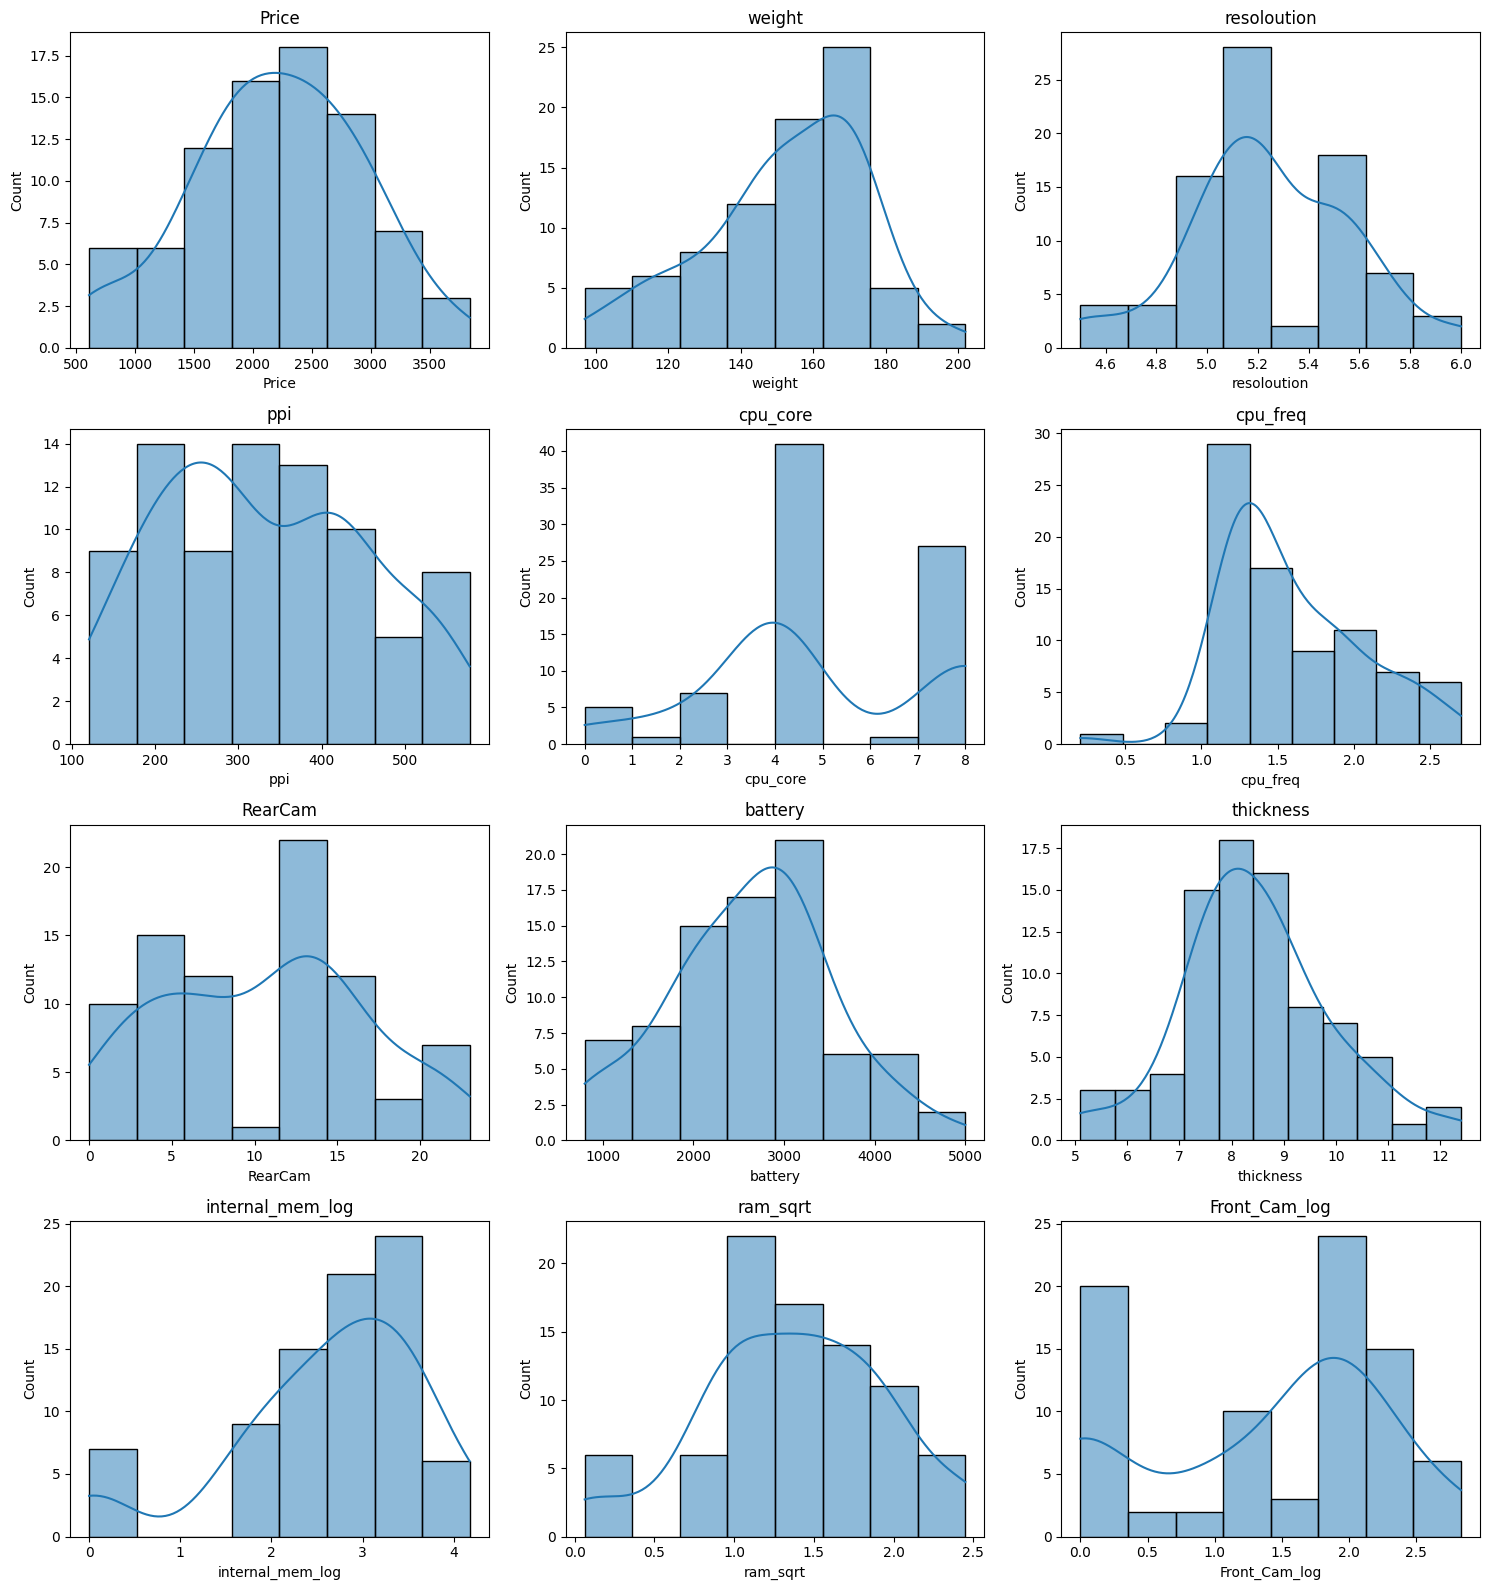

In [129]:
# plotting histograms for independent variables post transformation

cols = df_transformed.select_dtypes(include=np.number).columns
n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.histplot(df_transformed[col], kde=True, ax=ax)
    ax.set_title(col)

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

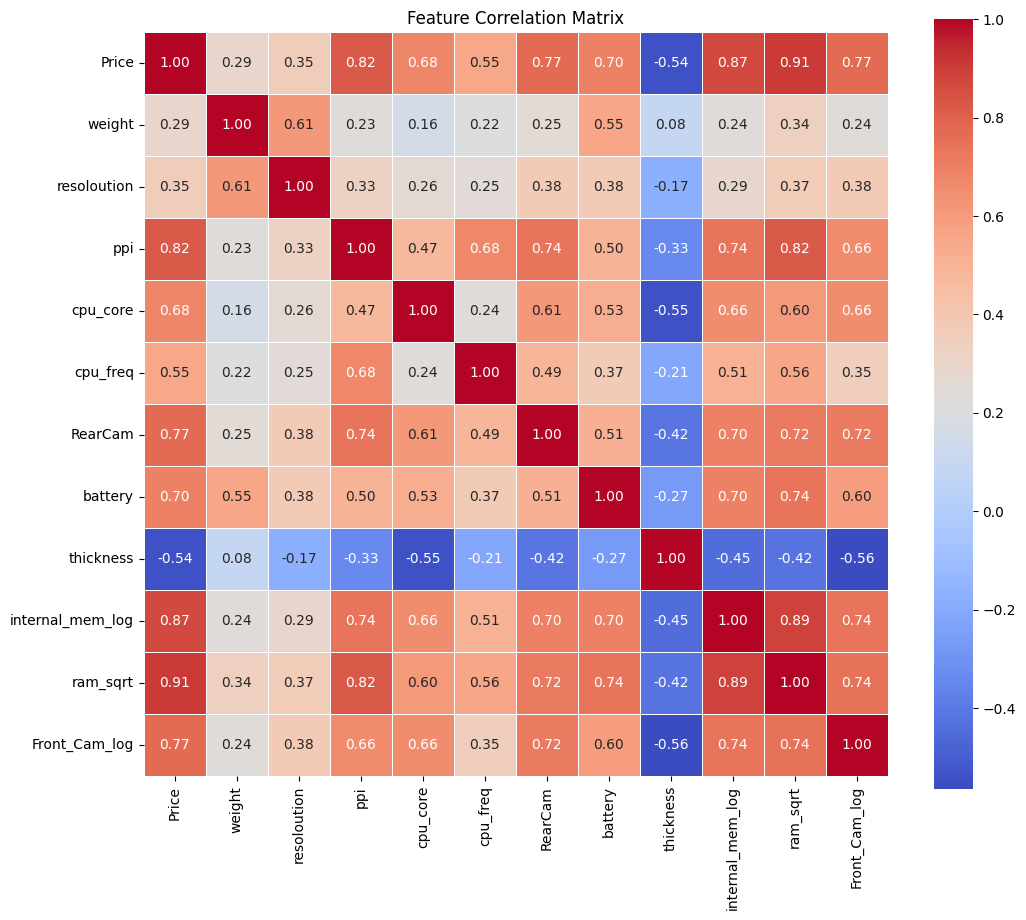

In [130]:
corr = df_transformed.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [131]:
# preparing data for modeling
x = df_transformed.drop('Price', axis=1)
y = df_transformed['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [132]:
def model_metrics(model, x_tr, y_tr, x_te, y_te):
    model.fit(x_tr, y_tr)
    y_tr_pred = model.predict(x_tr)
    y_te_pred = model.predict(x_te)
    return {
        "RMSE Train": np.sqrt(mean_squared_error(y_tr, y_tr_pred)),
        "RMSE Test": np.sqrt(mean_squared_error(y_te, y_te_pred)),
        "R2 Train": r2_score(y_tr, y_tr_pred),
        "R2 Test": r2_score(y_te, y_te_pred),
    }

models_to_compare = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5),
}

comparison = []

for model_name, model in models_to_compare.items():
    for scale_name, (X_tr, X_te) in [
        ("unscaled", (x_train, x_test)),
        ("scaled", (x_train_scaled, x_test_scaled))
    ]:
        metrics = model_metrics(model, X_tr, y_train, X_te, y_test)
        comparison.append({
            "Model": model_name,
            "Scaled": scale_name,
            **metrics
        })

performance_df = pd.DataFrame(comparison)
performance_df = performance_df.set_index(["Model", "Scaled"])
performance_df

RMSE Train   RMSE Test  R2 Train   R2 Test
Model            Scaled                                              
LinearRegression unscaled  227.767943  277.185408  0.902684  0.789419
                 scaled    227.767943  277.185408  0.902684  0.789419
Ridge            unscaled  228.115659  287.178419  0.902386  0.773961
                 scaled    227.858719  276.424703  0.902606  0.790573
Lasso            unscaled  227.891472  278.400650  0.902578  0.787568
                 scaled    227.832213  275.607824  0.902629  0.791809
ElasticNet       unscaled  238.788739  329.398637  0.893038  0.702612
                 scaled    242.071604  299.918404  0.890077  0.753461

In [133]:
#dump the best performing model
joblib.dump(models_to_compare['Lasso'], 'lasso_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [136]:
df_transformed.info()

<class 'pandas.DataFrame'>
Index: 82 entries, 0 to 158
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             82 non-null     float64
 1   weight            82 non-null     float64
 2   resoloution       82 non-null     float64
 3   ppi               82 non-null     int64  
 4   cpu_core          82 non-null     int64  
 5   cpu_freq          82 non-null     float64
 6   RearCam           82 non-null     float64
 7   battery           82 non-null     int64  
 8   thickness         82 non-null     float64
 9   internal_mem_log  82 non-null     float64
 10  ram_sqrt          82 non-null     float64
 11  Front_Cam_log     82 non-null     float64
dtypes: float64(9), int64(3)
memory usage: 10.4 KB
